# ResNet-50 + Wavelet Features (Hybrid) — Breast Cancer Classification
Based on: Mohanty & Das (2025), *ResNet-50 backbone + wavelet features for complementary information*.

Pipeline structure mirrors the EfficientNetB3 baseline notebook: frozen ImageNet backbone → pooled deep features,
fused with handcrafted wavelet features → dense classifier head. Same callbacks, same metrics (F1/Precision/Recall),
same evaluation + classification report + confusion matrix flow.

In [1]:
# ==========================================================
# INSTALL WAVELET LIBRARY (only needed once per environment)
# ==========================================================
# !pip install PyWavelets

print("start")

import os

Imbalanced_dataset = r"D:\Thesis_folder\Supervised_Imbalanced"

print("Imbalanced dataset ready")


start
Imbalanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence, to_categorical
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Supervised_Imbalanced"

IMAGE_SIZE = (320, 320)          # native ResNet-50 input size
MODEL_INPUT_SIZE = (320, 320, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 150

WAVELET_NAME = "db1"             # Daubechies-1 (Haar), matches common breast-cancer wavelet studies
WAVELET_LEVEL = 2                # decomposition depth -> richer complementary features

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [5]:
# ==========================================================
# WAVELET FEATURE EXTRACTION
# ==========================================================
# For each image we take a 2D Discrete Wavelet Transform (DWT) of the grayscale
# version, then summarise every sub-band (approximation + horizontal/vertical/
# diagonal detail) with mean, std and energy. This gives a compact, complementary
# texture descriptor that is concatenated with the ResNet-50 deep features,
# following the "ResNet-50 backbone + wavelet features for complementary
# information" design in Mohanty & Das (2025).

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    """
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector
    """
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)

    features = []
    for idx, c in enumerate(coeffs):
        if idx == 0:
            # approximation coefficients (single array)
            sub_bands = [c]
        else:
            # detail coefficients: tuple of (cH, cV, cD)
            sub_bands = list(c)

        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)  # normalised energy

    return np.array(features, dtype=np.float32)


def get_wavelet_feature_dim():
    """Run once on a dummy image to determine the wavelet feature vector length."""
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Wavelet feature vector length: {WAVELET_FEATURE_DIM}")


Wavelet feature vector length: 21


In [6]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet branch)
# ==========================================================
# ImageDataGenerator.flow_from_directory only yields (image, label) pairs, so a
# custom Sequence is used here to additionally compute the wavelet feature
# vector for every image in the batch. Directory layout is identical to the
# EfficientNetB3 notebook: DATASET_PATH/{train,val,test}/<class_name>/*.jpg

class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = {name: i for i, name in enumerate(self.class_names)}

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_indices[cls])

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            # Wavelet branch computed on the raw (0-255) resized image
            batch_wavelets[i] = extract_wavelet_features(img_rgb)

            # ResNet-50 branch uses its own preprocessing (caffe-style mean subtraction)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32).copy())

            batch_labels[i] = to_categorical(self.labels[fi], num_classes=self.num_classes)

        return (batch_images, batch_wavelets), batch_labels

    # Convenience properties to mirror ImageDataGenerator API used later in the notebook
    @property
    def classes(self):
        return self.labels

    @property
    def class_indices_(self):
        return self.class_indices


train_generator = ResNetWaveletGenerator(train_dir, shuffle=True)
val_generator = ResNetWaveletGenerator(val_dir, shuffle=False)
test_generator = ResNetWaveletGenerator(test_dir, shuffle=False)

print("Classes found:", train_generator.class_names)
print("Train / Val / Test sizes:",
      len(train_generator.filepaths), len(val_generator.filepaths), len(test_generator.filepaths))


Classes found: ['Benign', 'Malignant', 'Normal']
Train / Val / Test sizes: 13811 2960 2960


In [7]:
# ==========================================================
# CLASS WEIGHTS (NEW -- notebook is on the imbalanced dataset but
# model.fit() never used class_weight before)
# ==========================================================
print("start")

from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.labels),
    y=train_generator.labels
)
class_weight = dict(enumerate(class_weight_values))
print("Class weights:", class_weight)

print("done1")

start
Class weights: {0: 1.0837256748273698, 1: 0.7812093444199333, 2: 1.2544050862851952}
done1


In [8]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet MLP (feature branch)
# ==========================================================
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = tf.keras.metrics.Precision(name='precision')
recall_metric = tf.keras.metrics.Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid():
    # ---- Image branch: ResNet-50 (frozen, ImageNet weights) ----
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(0.3)(x_img)

    # ---- Wavelet branch: small MLP over handcrafted features ----
    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu')(x_wav)
    x_wav = Dropout(0.3)(x_wav)

    # ---- Fusion + classifier head ----
    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu')(fused)
    fused = Dropout(0.3)(fused)
    output = Dense(NUM_CLASSES, activation='softmax')(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    # Return base_model too -- avoids guessing which layer is the backbone
    # later (model.layers is flattened because base_model shares image_input,
    # so there is no single layer named "resnet50" to look up by name).
    return model, base_model

model, base_model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 320, 320, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 326, 326, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 160, 160, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [9]:
# ==========================================================
# CALLBACKS (Monitor set to 'val_f1_score')
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=11,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=5e-8,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "ResNet50_Wavelet_Hybrid_Imbalanced_model.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("done")


start
done


In [10]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [11]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight,   # NEW
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
print("done")


start
Epoch 1/150
432/432 [==============================] - ETA: 0s - loss: 0.9234 - accuracy: 0.5551 - f1_score: 0.5545 - precision: 0.6051 - recall: 0.4462
Epoch 1: val_f1_score improved from -inf to 0.63519, saving model to ResNet50_Wavelet_Hybrid_Imbalanced_model.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
432/432 [==============================] - 209s 476ms/step - loss: 0.9234 - accuracy: 0.5551 - f1_score: 0.5545 - precision: 0.6051 - recall: 0.4462 - val_loss: 0.7562 - val_accuracy: 0.6571 - val_f1_score: 0.6352 - val_precision: 0.7426 - val_recall: 0.5135 - lr: 1.0000e-04
Epoch 2/150
432/432 [==============================] - ETA: 0s - loss: 0.7797 - accuracy: 0.6256 - f1_score: 0.6250 - precision: 0.6783 - recall: 0.5328
Epoch 2: val_f1_score did not improve from 0.63519

Epoch 2 Learning Rate : 9.999999747378752e-05
432/432 [==============================] - 202s 466ms/step - loss: 0.7797 - accuracy: 0.6256 - f1_score: 0.6250 - precision: 0.6783 - recall: 0.5328 - val

In [12]:
# ==========================================================
# LOAD PHASE 1 (FROZEN BACKBONE) BEST WEIGHTS
# ==========================================================
# 1. Rebuild the model architecture blueprint first
model, base_model = get_ResNet50_Wavelet_Hybrid()

# 2. Load the weights directly into the blueprint
model.load_weights("ResNet50_Wavelet_Hybrid_Imbalanced_model.h5")

print("Phase 1 model weights loaded successfully!")

Phase 1 model weights loaded successfully!


In [13]:
# ==========================================================
# PHASE 2: FINE-TUNING CALLBACKS (NEW)
# ==========================================================
print("start")

early_stop_ft = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = ModelCheckpoint(
    "ResNet50_Wavelet_Hybrid_Imbalanced_FineTuned_model.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("done1")

start
done1


In [14]:
# ==========================================================
# PHASE 2: FINE-TUNE THE RESNET-50 BACKBONE (NEW)
# ==========================================================
# The frozen-backbone phase above plateaus regardless of which ResNet
# depth is used (50/101/152V2 all land within ~2 points of each other),
# which is the signature of a backbone that hasn't adapted to mammography
# features yet, not one that's out of capacity. This unfreezes the top
# of the backbone and continues training at a much lower learning rate.
print("start")

# base_model comes straight from get_ResNet50_Wavelet_Hybrid() (see cell 12) --
# no guessing needed, since model.layers is flattened and has no layer
# actually named "resnet50".
base_model.trainable = True
for layer in base_model.layers[:-30]:   # keep the earliest, most generic layers frozen
    layer.trainable = False
# keep BatchNorm layers in inference mode even where "trainable" -- avoids
# destabilizing running statistics with a small batch size at a low LR
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)   # much smaller than phase 1's 1e-4
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weight,   # NEW -- same weighting as phase 1
    callbacks=[
        early_stop_ft,
        reduce_lr_ft,
        checkpoint_ft,
        lr_callback
    ]
)

print("done")

start
Epoch 1/40
432/432 [==============================] - ETA: 0s - loss: 0.5580 - accuracy: 0.7348 - f1_score: 0.7371 - precision: 0.7779 - recall: 0.6824
Epoch 1: val_f1_score improved from -inf to 0.74296, saving model to ResNet50_Wavelet_Hybrid_Imbalanced_FineTuned_model.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
432/432 [==============================] - 211s 482ms/step - loss: 0.5580 - accuracy: 0.7348 - f1_score: 0.7371 - precision: 0.7779 - recall: 0.6824 - val_loss: 0.5976 - val_accuracy: 0.7449 - val_f1_score: 0.7430 - val_precision: 0.7784 - val_recall: 0.6834 - lr: 1.0000e-05
Epoch 2/40
432/432 [==============================] - ETA: 0s - loss: 0.5062 - accuracy: 0.7660 - f1_score: 0.7681 - precision: 0.7941 - recall: 0.7242
Epoch 2: val_f1_score did not improve from 0.74296

Epoch 2 Learning Rate : 9.999999747378752e-06
432/432 [==============================] - 201s 464ms/step - loss: 0.5062 - accuracy: 0.7660 - f1_score: 0.7681 - precision: 0.7941 - recall: 0.72

In [15]:
# ==========================================================
# LOAD PHASE 2 (FINE-TUNED) BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("ResNet50_Wavelet_Hybrid_Imbalanced_FineTuned_model.h5")

print("Fine-tuned model weights loaded successfully!")

Fine-tuned model weights loaded successfully!


start


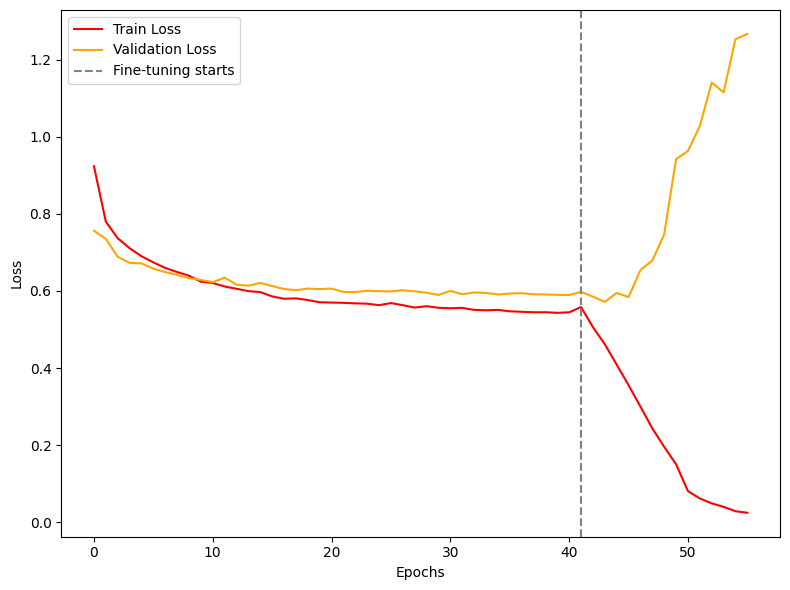

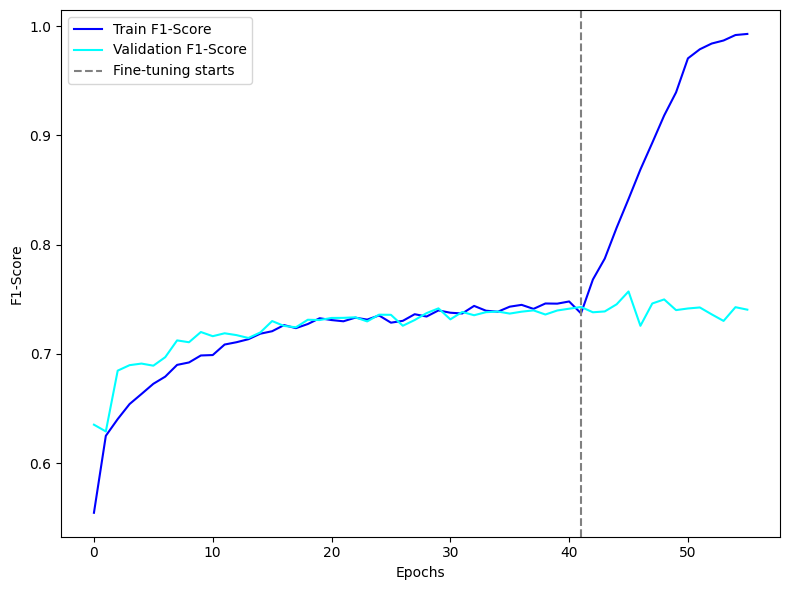

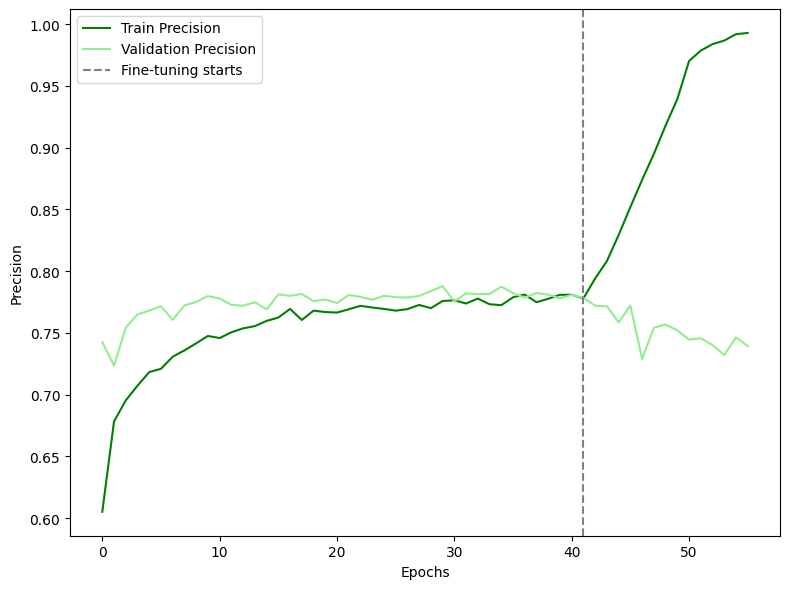

done1


In [16]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# Phase 1 (frozen) and Phase 2 (fine-tuned) are plotted as one continuous
# curve so you can see the effect of unfreezing at the join point (NEW).
# ==========================================================
print("start")

def concat_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

phase1_end = len(history.history['loss'])

# 1. Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'loss'), label='Train Loss', color='red')
plt.plot(concat_history(history, history_finetune, 'val_loss'), label='Validation Loss', color='orange')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_Loss_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 2. F1 Score Curve
plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'f1_score'), label='Train F1-Score', color='blue')
plt.plot(concat_history(history, history_finetune, 'val_f1_score'), label='Validation F1-Score', color='cyan')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_F1_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 3. Precision Curve
plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'precision'), label='Train Precision', color='green')
plt.plot(concat_history(history, history_finetune, 'val_precision'), label='Validation Precision', color='lightgreen')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_Precision_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")

In [17]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

# Order: [loss, accuracy, f1_score, precision, recall]
train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

print("\n" + "="*40)
print("TRAINING METRICS")
print("="*40)
print(f"Training Loss      : {train_loss:.4f}")
print(f"Training Accuracy  : {train_acc*100:.2f}%")
print(f"Training F1-Score  : {train_f1*100:.2f}%")
print(f"Training Precision : {train_precision*100:.2f}%")
print(f"Training Recall    : {train_recall*100:.2f}%")

print("\n" + "="*40)
print("VALIDATION METRICS")
print("="*40)
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_acc*100:.2f}%")
print(f"Validation F1-Score  : {val_f1*100:.2f}%")
print(f"Validation Precision : {val_precision*100:.2f}%")
print(f"Validation Recall    : {val_recall*100:.2f}%")

print("\n" + "="*40)
print("TESTING METRICS (UNSEEN DATA)")
print("="*40)
print(f"Testing Loss      : {test_loss:.4f}")
print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print(f"Testing F1-Score  : {test_f1*100:.2f}%")
print(f"Testing Precision : {test_precision*100:.2f}%")
print(f"Testing Recall    : {test_recall*100:.2f}%")


Evaluating on Training Set...
432/432 [==============================] - 172s 396ms/step - loss: 0.2521 - accuracy: 0.9009 - f1_score: 0.8749 - precision: 0.8801 - recall: 0.8626

Evaluating on Validation Set...
93/93 [==============================] - 37s 395ms/step - loss: 0.5840 - accuracy: 0.7574 - f1_score: 0.7572 - precision: 0.7722 - recall: 0.7385

Evaluating on Testing Set (Truly Unseen)...
93/93 [==============================] - 43s 460ms/step - loss: 0.5760 - accuracy: 0.7628 - f1_score: 0.7622 - precision: 0.7734 - recall: 0.7493

TRAINING METRICS
Training Loss      : 0.2521
Training Accuracy  : 90.09%
Training F1-Score  : 87.49%
Training Precision : 88.01%
Training Recall    : 86.26%

VALIDATION METRICS
Validation Loss      : 0.5840
Validation Accuracy  : 75.74%
Validation F1-Score  : 75.72%
Validation Precision : 77.22%
Validation Recall    : 73.85%

TESTING METRICS (UNSEEN DATA)
Testing Loss      : 0.5760
Testing Accuracy  : 76.28%
Testing F1-Score  : 76.22%
Testing Pre

In [18]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = test_generator.class_names

print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")



Calculating Precision, Recall, F1-score on Test Set...
93/93 [==============================] - 35s 370ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.69      0.63      0.66       911
   Malignant       0.77      0.78      0.78      1263
      Normal       0.82      0.89      0.85       786

    accuracy                           0.76      2960
   macro avg       0.76      0.77      0.76      2960
weighted avg       0.76      0.76      0.76      2960

done1


Generating Confusion Matrix...


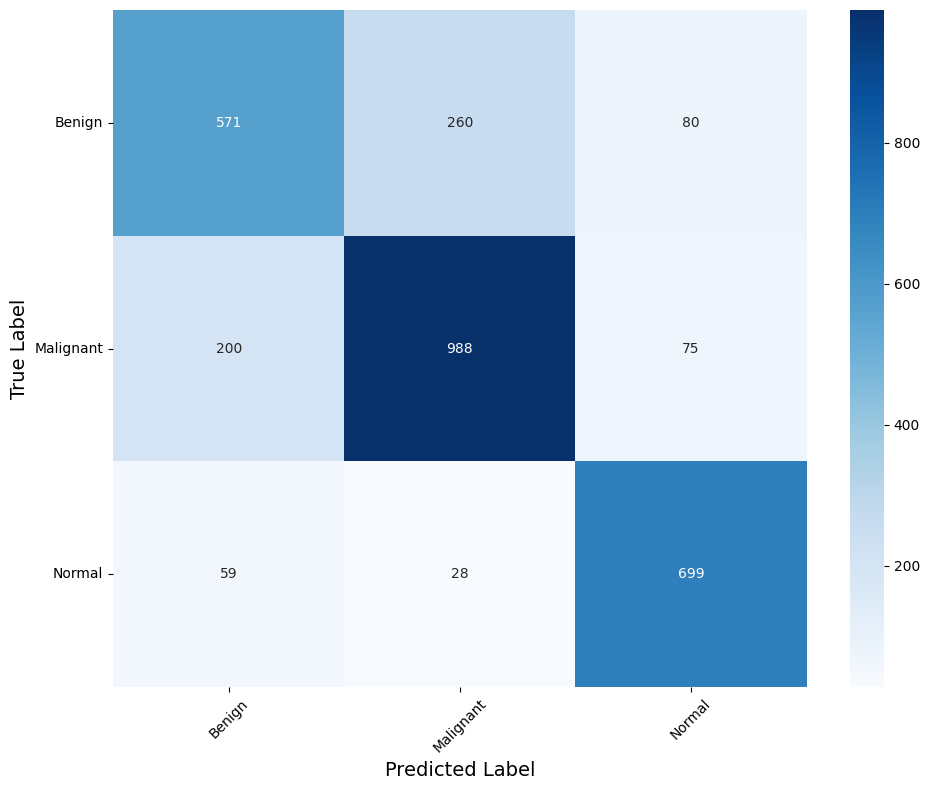

done1


In [19]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("ResNet50_Wavelet_Imbalanced_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")
